# Análisis de Grids Circulares y Propensity Score Matching

Este notebook itera sobre diferentes tamaños de redes circulares (radios) para evaluar la calidad del Matching a través del SMD (Standardized Mean Difference).

In [1]:
import os
import sys
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Agregar el directorio base (scripts) al path para importar las clases
sys.path.append(os.path.abspath('..'))

from ps_features_builder import PSFeaturesBuilder
from ps_matching import PSMatching

In [2]:
# Definición de rutas a los archivos
PATH_DATA = '../../data/'
PATHS = {
    'vialidades': os.path.join(PATH_DATA, 'vialidades.json'),
    'speed_cameras': os.path.join(PATH_DATA, 'fotocivicas-ubicacion-puntos', 'fotocivicas-ubicacion-puntos.shp'),
    'metro_coordinates': os.path.join(PATH_DATA, 'metro-station-coordinates.parquet'),
    'afluencia_metro': os.path.join(PATH_DATA, 'afluencia-metro-semanal.parquet'),
    'classified_incidents': os.path.join(PATH_DATA, 'classified-incidents.parquet'),
    'volumen_mensual': os.path.join(PATH_DATA, 'volumen-total-mensual.parquet')
}

## Iteración sobre tamaños de grids circulares
Evaluaremos los radios de 37.5, 50, 100, 150, 200 y 250 metros. Para los grids circulares, `n_circles` puede fijarse en 15 o un valor estándar para abarcar una zona adecuada.


Procesando Grid Circular con Radio: 37.5 m



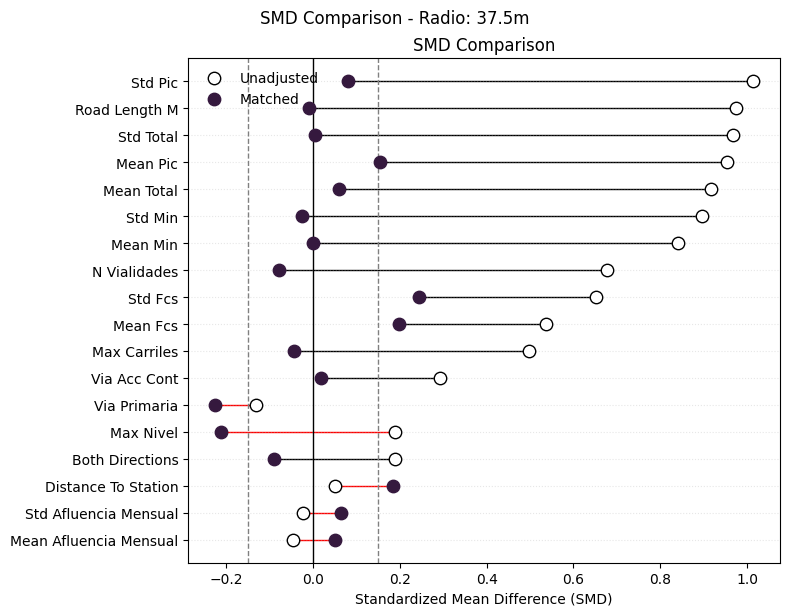


Stats del Matching:
  unidades_totales: 56947
  unidades_tratadas: 104
  unidades_control: 56843
  unidades_matched_tratadas: 104
  unidades_matched_control: 104
  mean_smd_after: 0.097
  sum_smd_after: 1.742

Procesando Grid Circular con Radio: 50 m



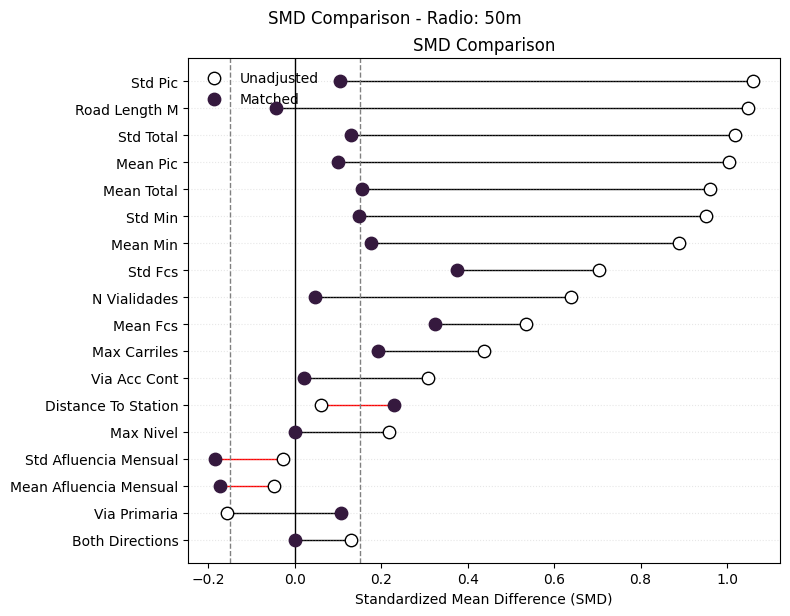


Stats del Matching:
  unidades_totales: 25952
  unidades_tratadas: 101
  unidades_control: 25851
  unidades_matched_tratadas: 101
  unidades_matched_control: 101
  mean_smd_after: 0.139
  sum_smd_after: 2.504

Procesando Grid Circular con Radio: 100 m



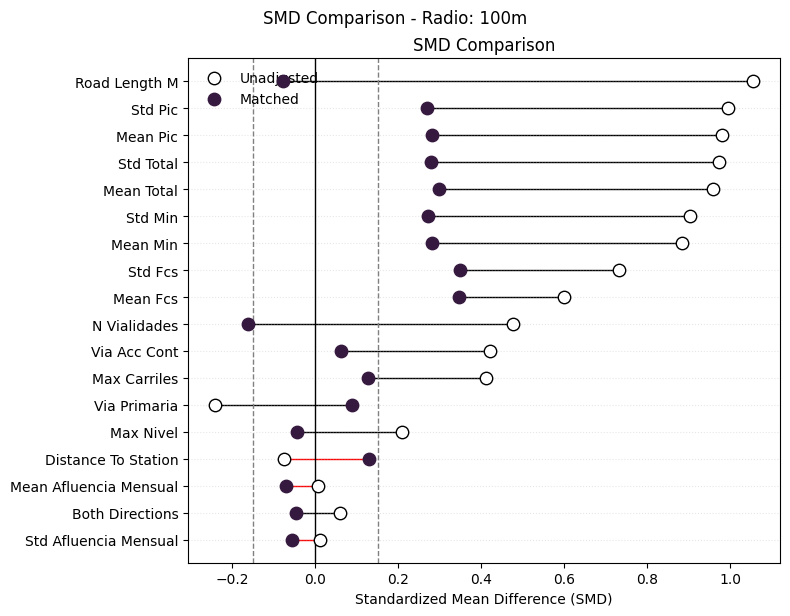


Stats del Matching:
  unidades_totales: 65655
  unidades_tratadas: 99
  unidades_control: 65556
  unidades_matched_tratadas: 99
  unidades_matched_control: 99
  mean_smd_after: 0.180
  sum_smd_after: 3.238

Procesando Grid Circular con Radio: 150 m



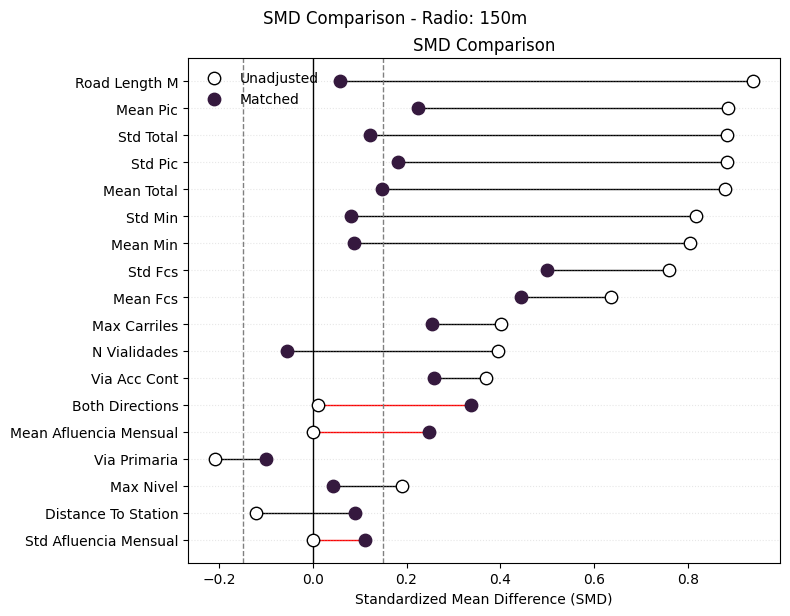


Stats del Matching:
  unidades_totales: 46959
  unidades_tratadas: 96
  unidades_control: 46863
  unidades_matched_tratadas: 96
  unidades_matched_control: 96
  mean_smd_after: 0.186
  sum_smd_after: 3.348

Procesando Grid Circular con Radio: 200 m



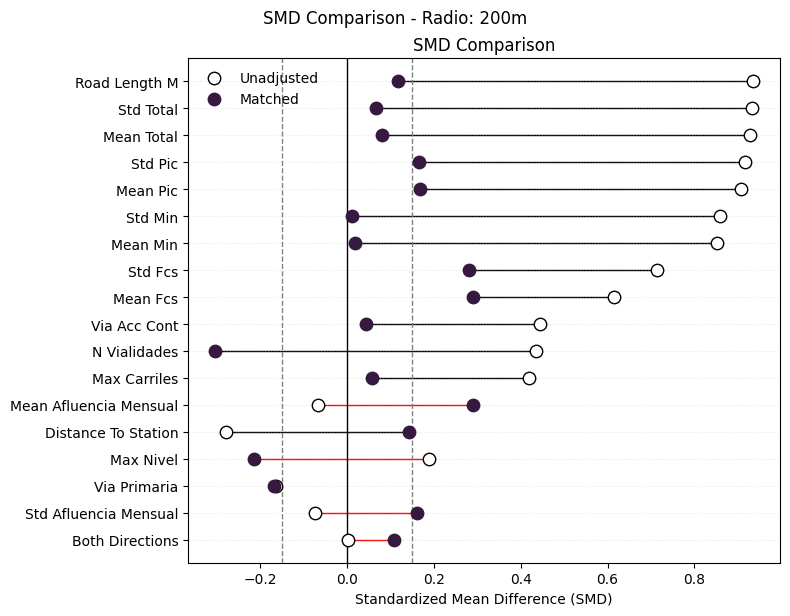


Stats del Matching:
  unidades_totales: 79795
  unidades_tratadas: 92
  unidades_control: 79703
  unidades_matched_tratadas: 92
  unidades_matched_control: 92
  mean_smd_after: 0.149
  sum_smd_after: 2.682

Procesando Grid Circular con Radio: 250 m



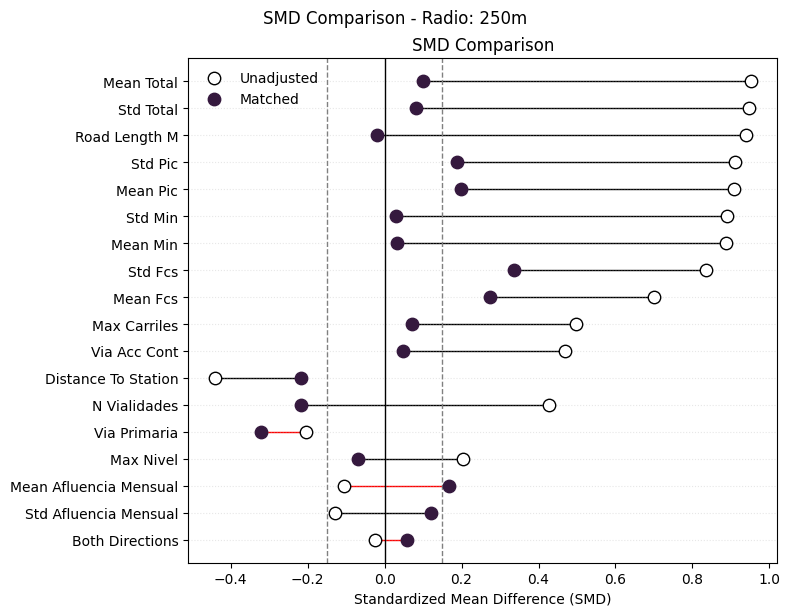


Stats del Matching:
  unidades_totales: 93182
  unidades_tratadas: 84
  unidades_control: 93098
  unidades_matched_tratadas: 84
  unidades_matched_control: 84
  mean_smd_after: 0.142
  sum_smd_after: 2.548


In [4]:
# radio, n_circles
radios = [
    (37.5, 25),
    (50, 15),
    (100, 20),
    (150, 15),
    (200, 20),
    (250, 25),
]

for radio, n_circles in radios:
    print(f"\n{'='*50}")
    print(f"Procesando Grid Circular con Radio: {radio} m")
    print(f"{'='*50}\n")
    
    # 1. Construcción de Features y Grids
    try:
        ps_builder = PSFeaturesBuilder(
            paths=PATHS,
            grid_type='circular',
            # grid_size=radio, # grid_size parameter is currently for rectangular, but circular radius works here too if we want to log it or we just use circle_radius
            circle_radius=radio,
            n_circles=n_circles
        )
        ps_builder.build()
        
        # 2. Matching
        psm = PSMatching(
            ps_features=ps_builder.ps_features,
            grid=ps_builder.grid,
            outcome=ps_builder.outcome,
            grid_type='circular',
            grid_size=radio # Importante para excluir features en el modelo Logit según el dict DROP_COLUMNS_DICT_CIRCULAR
        )
        psm.build(matching_method='nearest', n_matches=1, replace=False)
        
        # 3. Mostrar Plot SMD
        fig = psm.plot_smd_comparison(figsize=(8, 6))
        fig.suptitle(f'SMD Comparison - Radio: {radio}m', y=1.02)
        plt.show()
        
        # Mostrar algunas stats
        stats = psm.get_summary_stats()
        print("\nStats del Matching:")
        for k, v in stats.items():
            print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")
            
    except Exception as e:
        print(f"Error al procesar el radio {radio}: {e}")